# Homework 2 — Response Clarity Classification
**Course:** Artificial Intelligence II — Deep Learning for NLP  
**Dataset:** SemEval 2026 Task 6 (QEvasion)  
**Model:** `bert-base-uncased`  
**Metric:** Macro F1-Score  

---
### Input Construction Design

We pass the question and answer as **two separate sequences** to the tokenizer:

```
BERT: [CLS] <question> [SEP] <answer> [SEP]
```

The tokenizer handles separator injection and segment IDs (`token_type_ids`) automatically.
This mirrors the standard NSP pre-training format for BERT and gives the model an explicit
Q/A boundary without manual text manipulation.

In [1]:
# Download all model files to a local folder — avoids HF streaming hangs on Kaggle
from huggingface_hub import snapshot_download
BERT_LOCAL_DIR = snapshot_download(repo_id='bert-base-uncased')
print('Downloaded to:', BERT_LOCAL_DIR)

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

Downloaded to: /root/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594


In [2]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"] = "120"
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from datasets import load_dataset
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
COLORS = ["#4C72B0", "#DD8452", "#55A868"]
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

SEED = 42
def seed_all(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
seed_all(SEED)


Device: cuda
GPU: Tesla T4


## 1. Load Data

In [3]:
ds       = load_dataset("ailsntua/QEvasion")
df_train = pd.DataFrame(ds["train"])
df_test  = pd.DataFrame(ds["test"])

print("Train size:", len(df_train))
print("Test  size:", len(df_test))
print("\nLabel distribution (train):")
print(df_train["clarity_label"].value_counts())
df_train.head(3)

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

Train size: 3448
Test  size: 308

Label distribution (train):
clarity_label
Ambivalent         2040
Clear Reply        1052
Clear Non-Reply     356
Name: count, dtype: int64


,title,date,president,url,question_order,interview_question,interview_answer,gpt3.5_summary,gpt3.5_prediction,question,annotator_id,annotator1,annotator2,annotator3,inaudible,multiple_questions,affirmative_questions,index,clarity_label,evasion_label
0,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,How would you respond to the accusation that t...,85,None,None,None,False,False,False,0,Clear Reply,Explicit
1,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,1,Q. Of the Biden administration. And accused th...,"Well, look, first of all, theI am sincere abou...",The question consists of 2 parts: \n1. How wou...,Question part: 1. How would you respond to the...,Do you think President Xi is being sincere abo...,85,None,None,None,False,False,False,1,Ambivalent,General
2,"The President's News Conference in Hanoi, Vietnam","September 10, 2023",Joseph R. Biden,https://www.presidency.ucsb.edu/documents/the-...,2,Q. No worries. Do you believe the country's sl...,"Look, I think China has a difficult economic p...",The question consists of two parts:\n\n1. Q1: ...,Question part: Q1 - Do you believe the country...,Do you believe the country's slowdown and gro...,85,None,None,None,False,False,False,2,Ambivalent,Partial/half-answer


## 2. Exploratory Data Analysis

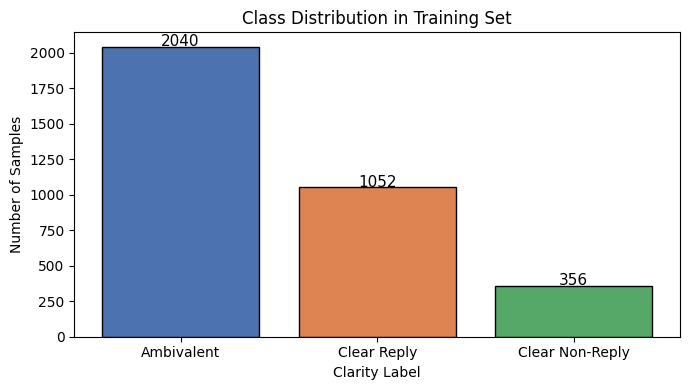

In [4]:
label_counts = df_train["clarity_label"].value_counts()

plt.figure(figsize=(7, 4))
bars = plt.bar(label_counts.index, label_counts.values, color=COLORS, edgecolor="black")
for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
             str(val), ha="center", fontsize=11)
plt.title("Class Distribution in Training Set")
plt.xlabel("Clarity Label")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig("eda_class_distribution_bert.png", dpi=300)
plt.show()

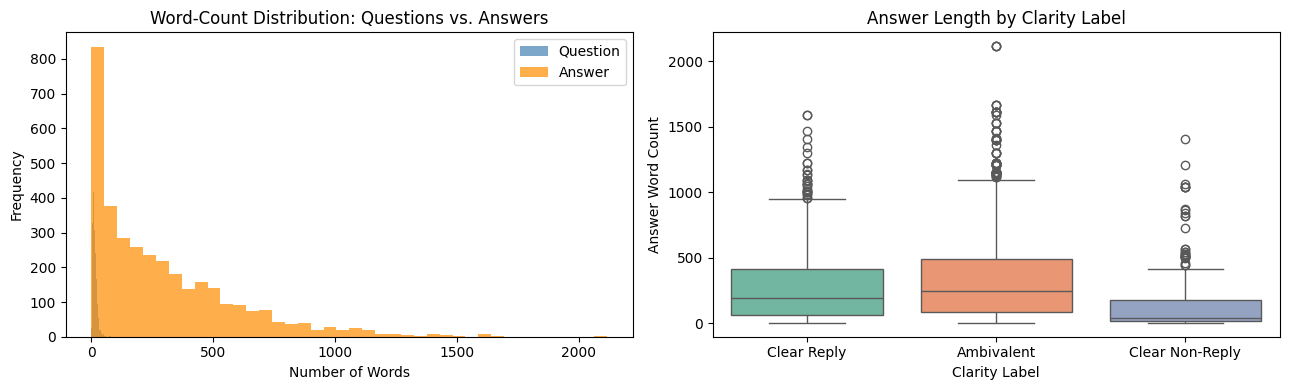


Median answer length per class:
clarity_label
Ambivalent         243.5
Clear Non-Reply     39.5
Clear Reply        194.0
Name: a_length, dtype: float64


In [5]:
df_train["q_length"] = df_train["question"].apply(lambda x: len(str(x).split()))
df_train["a_length"] = df_train["interview_answer"].apply(lambda x: len(str(x).split()))
df_test["q_length"]  = df_test["question"].apply(lambda x: len(str(x).split()))
df_test["a_length"]  = df_test["interview_answer"].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df_train["q_length"], bins=40, alpha=0.7, label="Question", color="steelblue")
axes[0].hist(df_train["a_length"], bins=40, alpha=0.7, label="Answer",   color="darkorange")
axes[0].set_title("Word-Count Distribution: Questions vs. Answers")
axes[0].set_xlabel("Number of Words"); axes[0].set_ylabel("Frequency"); axes[0].legend()

sns.boxplot(
    data=df_train, x="clarity_label", y="a_length", hue="clarity_label",
    order=["Clear Reply", "Ambivalent", "Clear Non-Reply"],
    palette="Set2", legend=False, ax=axes[1],
)
axes[1].set_title("Answer Length by Clarity Label")
axes[1].set_xlabel("Clarity Label"); axes[1].set_ylabel("Answer Word Count")

plt.tight_layout(); plt.savefig("eda_lengths_bert.png", dpi=300); plt.show()
print("\nMedian answer length per class:")
print(df_train.groupby("clarity_label")["a_length"].median())

## 3. Label Encoding & Train / Validation Split

In [6]:
LABELS     = ["Clear Reply", "Ambivalent", "Clear Non-Reply"]
LABEL2ID   = {l: i for i, l in enumerate(LABELS)}
ID2LABEL   = {i: l for l, i in LABEL2ID.items()}
NUM_LABELS = len(LABELS)

df_train["label_id"] = df_train["clarity_label"].map(LABEL2ID)

df_tr, df_val = train_test_split(
    df_train, test_size=0.10, stratify=df_train["label_id"], random_state=RANDOM_SEED,
)
df_tr  = df_tr.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)

print(f"Train subset : {len(df_tr)}   Validation : {len(df_val)}")
print("Val label distribution:")
print(df_val["clarity_label"].value_counts())

Train subset : 3103   Validation : 345
Val label distribution:
clarity_label
Ambivalent         204
Clear Reply        105
Clear Non-Reply     36
Name: count, dtype: int64


## 4. Shared Utilities

In [7]:
seed_all(SEED)  # Re-seed before model init
class ClarityDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, has_labels=True):
        self.questions  = df["question"].tolist()
        self.answers    = df["interview_answer"].tolist()
        self.labels     = df["label_id"].tolist() if has_labels else None
        self.tokenizer  = tokenizer
        self.max_len    = max_len
        self.has_labels = has_labels

    def __len__(self):
        return len(self.questions)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.questions[idx]),
            str(self.answers[idx]),
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        item = {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
        }
        if "token_type_ids" in enc:   # BERT uses token_type_ids
            item["token_type_ids"] = enc["token_type_ids"].squeeze(0)
        if self.has_labels:
            item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


def make_loaders(df_tr, df_val, df_test, tokenizer, max_len, batch_size):
    g = torch.Generator(); g.manual_seed(RANDOM_SEED)
    return (
        DataLoader(ClarityDataset(df_tr,   tokenizer, max_len, has_labels=True),
                   batch_size=batch_size, shuffle=True,  num_workers=0, generator=g),
        DataLoader(ClarityDataset(df_val,  tokenizer, max_len, has_labels=True),
                   batch_size=batch_size, shuffle=False, num_workers=0),
        DataLoader(ClarityDataset(df_test, tokenizer, max_len, has_labels=False),
                   batch_size=batch_size, shuffle=False, num_workers=0),
    )


def _forward(model, batch, device):
    kwargs = {
        "input_ids":      batch["input_ids"].to(device),
        "attention_mask": batch["attention_mask"].to(device),
    }
    if "token_type_ids" in batch:
        kwargs["token_type_ids"] = batch["token_type_ids"].to(device)
    return model(**kwargs)


def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        optimizer.zero_grad()
        labels  = batch["labels"].to(device)
        outputs = _forward(model, batch, device)
        loss    = loss_fn(outputs.logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step(); scheduler.step()
        total_loss += loss.item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro")


@torch.no_grad()
def eval_epoch(model, loader, loss_fn, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for batch in loader:
        labels  = batch["labels"].to(device)
        outputs = _forward(model, batch, device)
        total_loss += loss_fn(outputs.logits, labels).item()
        all_preds.extend(outputs.logits.argmax(dim=-1).cpu().tolist())
        all_labels.extend(labels.cpu().tolist())
    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro"), all_preds, all_labels


@torch.no_grad()
def predict(model, loader, device):
    model.eval()
    all_preds = []
    for batch in loader:
        all_preds.extend(_forward(model, batch, device).logits.argmax(dim=-1).cpu().tolist())
    return all_preds


def run_training(local_dir, df_tr, df_val, df_test,
                 max_len=256, batch_size=16, lr=2e-5,
                 num_epochs=5, warmup_ratio=0.10, patience=2):
    model_name = "bert-base-uncased"
    print(f"\n{'='*60}\n  MODEL : {model_name}\n{'='*60}")

    # Load tokenizer and model from local directory — no network calls
    tokenizer = AutoTokenizer.from_pretrained(local_dir)
    train_loader, val_loader, test_loader = make_loaders(
        df_tr, df_val, df_test, tokenizer, max_len, batch_size
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        local_dir, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    ).to(DEVICE)
    print(f"Parameters : {sum(p.numel() for p in model.parameters()):,}")

    class_weights = compute_class_weight(
        "balanced", classes=np.array([0, 1, 2]), y=df_tr["label_id"].values
    )
    loss_fn = nn.CrossEntropyLoss(
        weight=torch.tensor(class_weights, dtype=torch.float).to(DEVICE)
    )
    print(f"Class weights: {dict(zip(LABELS, class_weights.round(3)))}")

    no_decay = ["bias", "LayerNorm.weight"]
    param_groups = [
        {"params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
         "weight_decay": 0.01},
        {"params": [p for n, p in model.named_parameters() if     any(nd in n for nd in no_decay)],
         "weight_decay": 0.0},
    ]
    optimizer   = AdamW(param_groups, lr=lr)
    total_steps = len(train_loader) * num_epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(warmup_ratio * total_steps),
        num_training_steps=total_steps,
    )

    history      = {"train_loss": [], "val_loss": [], "train_f1": [], "val_f1": []}
    best_val_f1  = 0.0
    best_wts     = copy.deepcopy(model.state_dict())
    patience_cnt = 0

    for epoch in range(1, num_epochs + 1):
        tr_loss, tr_f1        = train_epoch(model, train_loader, optimizer, scheduler, loss_fn, DEVICE)
        vl_loss, vl_f1, _, _ = eval_epoch(model, val_loader, loss_fn, DEVICE)
        history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
        history["train_f1"].append(tr_f1);    history["val_f1"].append(vl_f1)
        print(f"  Epoch {epoch}/{num_epochs}  train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f}  "
              f"train_f1={tr_f1:.4f}  val_f1={vl_f1:.4f}")
        if vl_f1 > best_val_f1:
            best_val_f1  = vl_f1
            best_wts     = copy.deepcopy(model.state_dict())
            patience_cnt = 0
            print(f"    >> New best val Macro F1: {best_val_f1:.4f}")
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                print("    >> Early stopping triggered."); break

    model.load_state_dict(best_wts)
    _, _, val_preds_raw, val_labels_raw = eval_epoch(model, val_loader, loss_fn, DEVICE)
    val_preds_str  = [ID2LABEL[p] for p in val_preds_raw]
    val_labels_str = [ID2LABEL[l] for l in val_labels_raw]
    test_preds_str = [ID2LABEL[p] for p in predict(model, test_loader, DEVICE)]

    return model, tokenizer, history, val_preds_str, val_labels_str, test_preds_str

## 5. Hyperparameter Choices

| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | 2e-5 | Standard for BERT-scale fine-tuning; prevents catastrophic forgetting. |
| Epochs | 5 + early stopping | Enough to converge; patience=2 on val Macro F1 prevents overfitting. |
| Batch size | 16 | Balances GPU memory and gradient quality. |
| Max sequence length | 256 | Covers ≥95% of Q+A pairs without excessive padding. |
| Warmup ratio | 10% | Stabilises early updates before LR decays. |
| Weight decay | 0.01 | Applied to non-bias/non-LN params (decoupled AdamW). |
| Grad clip | 1.0 | Prevents gradient explosion in early fine-tuning. |
| Class weights | balanced | Compensates for label imbalance (Ambivalent >> Clear Non-Reply). |

---
# Model — `bert-base-uncased`

In [8]:
bert_model, bert_tok, bert_hist, bert_val_preds, bert_val_labels, bert_test_preds = run_training(
    local_dir=BERT_LOCAL_DIR,
    df_tr=df_tr, df_val=df_val, df_test=df_test,
)


  MODEL : bert-base-uncased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: /root/.cache/huggingface/hub/models--bert-base-uncased/snapshots/86b5e0934494bd15c9632b12f734a8a67f723594
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the chec

Parameters : 109,484,547
Class weights: {'Clear Reply': np.float64(1.092), 'Ambivalent': np.float64(0.563), 'Clear Non-Reply': np.float64(3.232)}
  Epoch 1/5  train_loss=1.0508  val_loss=0.7796  train_f1=0.4150  val_f1=0.5926
    >> New best val Macro F1: 0.5926
  Epoch 2/5  train_loss=0.8107  val_loss=0.7248  train_f1=0.6069  val_f1=0.6530
    >> New best val Macro F1: 0.6530
  Epoch 3/5  train_loss=0.6019  val_loss=0.7209  train_f1=0.7358  val_f1=0.6563
    >> New best val Macro F1: 0.6563
  Epoch 4/5  train_loss=0.4397  val_loss=0.7981  train_f1=0.8136  val_f1=0.6633
    >> New best val Macro F1: 0.6633
  Epoch 5/5  train_loss=0.3363  val_loss=0.8281  train_f1=0.8711  val_f1=0.6512


## 6. Training Curves

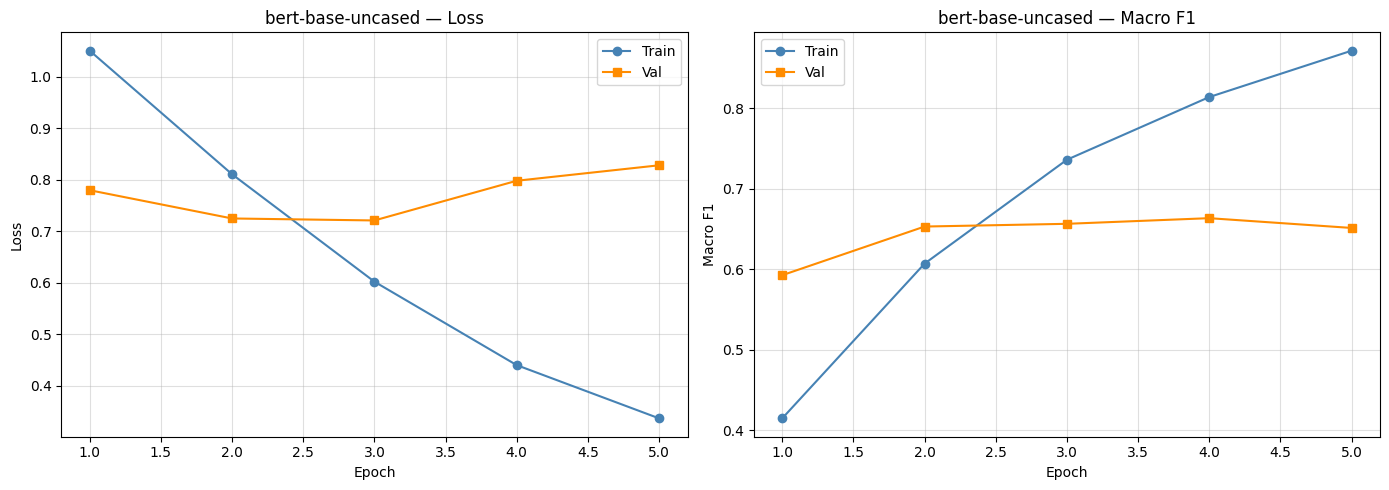

In [9]:
ep = range(1, len(bert_hist["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ep, bert_hist["train_loss"], marker="o", label="Train", color="steelblue")
axes[0].plot(ep, bert_hist["val_loss"],   marker="s", label="Val",   color="darkorange")
axes[0].set_title("bert-base-uncased — Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[1].plot(ep, bert_hist["train_f1"], marker="o", label="Train", color="steelblue")
axes[1].plot(ep, bert_hist["val_f1"],   marker="s", label="Val",   color="darkorange")
axes[1].set_title("bert-base-uncased — Macro F1"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Macro F1")
axes[1].legend(); axes[1].grid(True, alpha=0.4)
plt.tight_layout(); plt.savefig("training_curves_bert.png", dpi=300); plt.show()

## 7. Evaluation — Validation Set

=== bert-base-uncased — Validation Results ===
                 precision    recall  f1-score   support

    Clear Reply       0.76      0.72      0.74       204
     Ambivalent       0.65      0.61      0.63        36
Clear Non-Reply       0.58      0.67      0.62       105

       accuracy                           0.69       345
      macro avg       0.66      0.66      0.66       345
   weighted avg       0.70      0.69      0.69       345



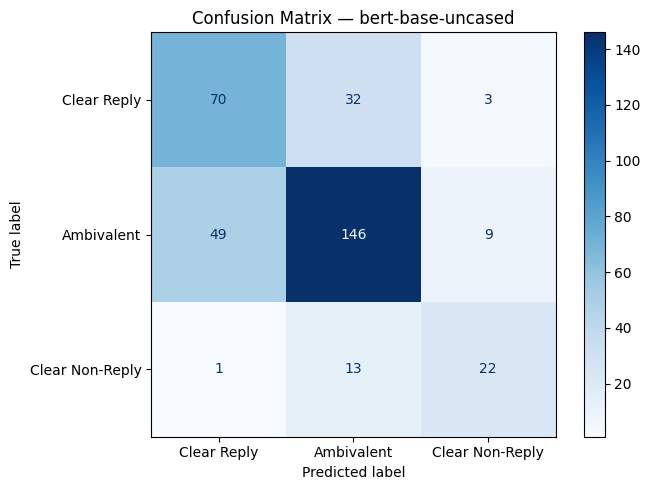

In [10]:
print("=== bert-base-uncased — Validation Results ===")
print(classification_report(bert_val_labels, bert_val_preds, target_names=LABELS))
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(bert_val_labels, bert_val_preds, labels=LABELS),
    display_labels=LABELS,
).plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("Confusion Matrix — bert-base-uncased")
plt.tight_layout(); plt.savefig("confusion_matrix_bert.png", dpi=300); plt.show()

In [11]:
y_true, y_pred = bert_val_labels, bert_val_preds
print("="*60)
print(f"Model     : bert-base-uncased")
print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro F1  : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"Precision : {precision_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true, y_pred, average='macro', zero_division=0):.4f}")
print("="*60)

Model     : bert-base-uncased
Accuracy  : 0.6899
Macro F1  : 0.6633
Precision : 0.6649
Recall    : 0.6645


## 8. Error Analysis

=== Error Analysis: bert-base-uncased ===
Errors: 107 / 345  (31.0%)
Confusion breakdown (true -> predicted):
     true_label      pred_label  count
     Ambivalent Clear Non-Reply      9
     Ambivalent     Clear Reply     49
Clear Non-Reply      Ambivalent     13
Clear Non-Reply     Clear Reply      1
    Clear Reply      Ambivalent     32
    Clear Reply Clear Non-Reply      3

 Hardest class: Ambivalent
  Q: Clear objective for talks with Kim Jong Un
  A: I have a clear objective. But I have to say, Eliana, that it's going to be something that will always be spur of the moment. You don't know. You know, this has not been done before
  True: Ambivalent  |  Pred: Clear Reply
  ------------------------------------------------------------
  Q: Do you think now, with the rising prices and the record high oil prices, it's time to change course?
  A: In this case, I have analyzed the issue. And I don't think it would affect price for this reason: We're buying, at the moment, about 67,000 

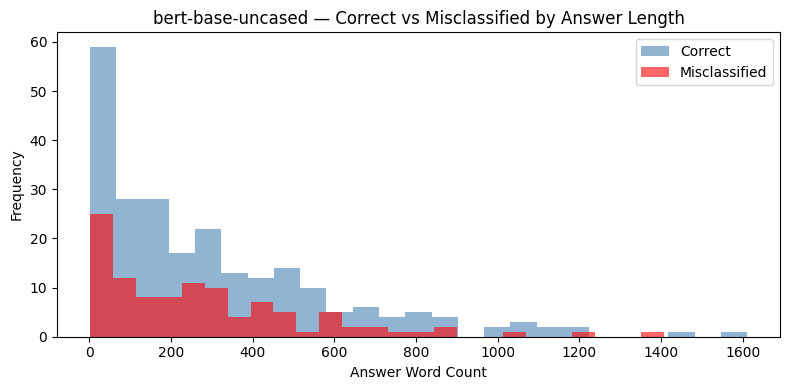

In [12]:
df_err = df_val.copy()
df_err["true_label"] = bert_val_labels
df_err["pred_label"] = bert_val_preds
df_err["correct"]    = (df_err["true_label"] == df_err["pred_label"]).astype(int)
errors = df_err[df_err["correct"] == 0]

print(f"=== Error Analysis: bert-base-uncased ===")
print(f"Errors: {len(errors)} / {len(df_err)}  ({100*len(errors)/len(df_err):.1f}%)")
print("Confusion breakdown (true -> predicted):")
print(errors.groupby(["true_label", "pred_label"]).size().reset_index(name="count").to_string(index=False))

hardest = errors["true_label"].value_counts().idxmax()
print(f"\n Hardest class: {hardest}")
for _, row in errors[errors["true_label"] == hardest].head(2).iterrows():
    print(f"  Q: {str(row['question'])[:120]}")
    print(f"  A: {str(row['interview_answer'])[:180]}")
    print(f"  True: {row['true_label']}  |  Pred: {row['pred_label']}")
    print("  " + "-"*60)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df_err[df_err["correct"]==1]["a_length"], bins=25, alpha=0.6, label="Correct",       color="steelblue")
ax.hist(df_err[df_err["correct"]==0]["a_length"], bins=25, alpha=0.6, label="Misclassified", color="red")
ax.set_xlabel("Answer Word Count"); ax.set_ylabel("Frequency")
ax.set_title("bert-base-uncased — Correct vs Misclassified by Answer Length")
ax.legend()
plt.tight_layout(); plt.savefig("error_analysis_bert.png", dpi=300); plt.show()

In [13]:
for col in ["q_length", "a_length"]:
    bins = pd.qcut(df_err[col], 4, duplicates="drop")
    acc_by_bin = df_err.groupby(bins)["correct"].mean().round(4)
    print(f"\nAccuracy by {col} quartile:")
    print(acc_by_bin)


Accuracy by q_length quartile:
q_length
(0.999, 8.0]    0.6630
(8.0, 13.0]     0.6897
(13.0, 19.0]    0.6517
(19.0, 74.0]    0.7662
Name: correct, dtype: float64

Accuracy by a_length quartile:
a_length
(0.999, 63.0]      0.6782
(63.0, 219.0]      0.7093
(219.0, 440.0]     0.6437
(440.0, 1611.0]    0.7294
Name: correct, dtype: float64


/tmp/ipykernel_23/3633021895.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = df_err.groupby(bins)["correct"].mean().round(4)
/tmp/ipykernel_23/3633021895.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acc_by_bin = df_err.groupby(bins)["correct"].mean().round(4)


## 9. Generate Submission

In [14]:
import glob as glob_module

sample_paths = glob_module.glob("/kaggle/input/**/sample_submission.csv", recursive=True)
if sample_paths:
    sample_sub = pd.read_csv(sample_paths[0])
    submission = pd.DataFrame({"Id": sample_sub["Id"], "Predicted": bert_test_preds})
else:
    submission = pd.DataFrame({"Id": df_test["index"], "Predicted": bert_test_preds})

submission.to_csv("/kaggle/working/submission_bert-base-uncased.csv", index=False)
submission.to_csv("/kaggle/working/submission.csv", index=False)
print("submission_bert-base-uncased.csv saved.")
print(pd.Series(bert_test_preds).value_counts())
submission.head()

submission_bert-base-uncased.csv saved.
Ambivalent         203
Clear Reply         81
Clear Non-Reply     24
Name: count, dtype: int64


,Id,Predicted
0,0,Ambivalent
1,1,Ambivalent
2,2,Ambivalent
3,3,Ambivalent
4,4,Clear Reply
